## Task 9: Error Analysis  

This section focuses on analyzing and understanding the errors made by the Persian emotion classification model.  
The goal is to identify **where** and **why** the model misclassifies emotions, uncover recurring patterns,  
and suggest improvements for future iterations.

Error analysis is a key step in NLP evaluation because it connects numerical performance to real linguistic behavior.  
While accuracy and F1-scores show *how well* a model performs, they do not explain *what goes wrong* or *why*.  
By studying the types of misclassifications, sentence characteristics, and confusion trends,  
we can better understand the model’s limitations and guide targeted improvements.

For this analysis, we used predictions from the **best performing model**.  

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [17]:
results_df = pd.read_csv("C:\\Users\\ASUS\\Desktop\\YEAR2-1\\TASK 9\\emotion_predictions.csv")
print("✅ Loaded results:", results_df.shape)
results_df.head()


✅ Loaded results: (1151, 3)


,Text,True_Emotion,Predicted_Emotion
0,اين شايد اولين عزاى عمومى واقعى است كه ياد دار...,1,1
1,دیشب بعد از ارسال تویت مربوط به آثار باستانی ت...,0,1
2,کدوم شعبه پول نداده، بگو الان برات آمار دقیق ...,6,3
3,امروز وسط یه بحث با بابا مامانم گفتم آدم باید ...,0,0
4,امشب گفت نامزدی دوستش که ادم روشنفکری است بهم ...,1,5


## 3. Quick Performance Overview

In [18]:
total = len(results_df)
correct = (results_df["True_Emotion"] == results_df["Predicted_Emotion"]).sum()
accuracy = correct / total * 100

print(f"Total Samples: {total}")
print(f"Correct Predictions: {correct}")
print(f"Overall Accuracy: {accuracy:.2f}%")


Total Samples: 1151
Correct Predictions: 652
Overall Accuracy: 56.65%


## 4. Per-Class Metrics (Classification Report)

In [19]:
print(classification_report(
    results_df["True_Emotion"],
    results_df["Predicted_Emotion"],
    digits=3
))


              precision    recall  f1-score   support

           0      0.748     0.691     0.718       275
           1      0.617     0.634     0.625       262
           2      0.713     0.393     0.507       145
           3      0.405     0.695     0.512       154
           4      0.000     0.000     0.000        65
           5      0.476     0.860     0.613        57
           6      0.459     0.430     0.444       193

    accuracy                          0.566      1151
   macro avg      0.488     0.529     0.488      1151
weighted avg      0.564     0.566     0.551      1151



c:\Anaconda\envs\YEAR2-1\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Anaconda\envs\YEAR2-1\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Anaconda\envs\YEAR2-1\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 5. Confusion Matrix Plot

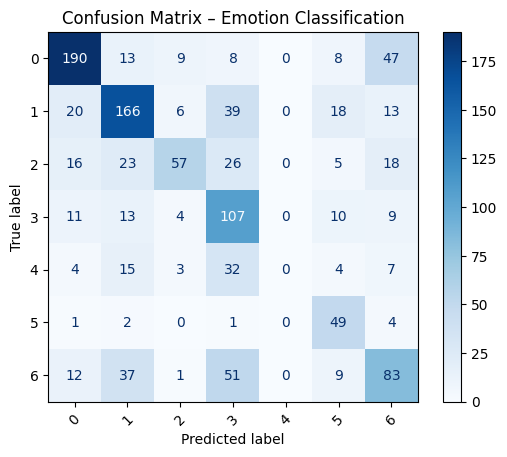

In [20]:
unique_labels = sorted(results_df["True_Emotion"].unique())
cm = confusion_matrix(results_df["True_Emotion"], results_df["Predicted_Emotion"], labels=unique_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix – Emotion Classification")
plt.show()


## 6. View Misclassified Examples

In [21]:
errors_df = results_df[results_df["True_Emotion"] != results_df["Predicted_Emotion"]]
print(f"Total Misclassifications: {len(errors_df)}")
errors_df.head(10)


Total Misclassifications: 499


,Text,True_Emotion,Predicted_Emotion
1,دیشب بعد از ارسال تویت مربوط به آثار باستانی ت...,0,1
2,کدوم شعبه پول نداده، بگو الان برات آمار دقیق ...,6,3
4,امشب گفت نامزدی دوستش که ادم روشنفکری است بهم ...,1,5
8,فن مترو خراب بود. ملت داشتن غر میزدن. آقای میا...,2,1
13,#دانلود #فیلمنامه «جانوران شگفت انگیز: جنایات ...,6,0
15,دیدم حمیدرضا عارف در مصاحبه با انصاف نیوز گله ...,4,1
20,این یافا عجب میوه بیخودیه، بوی تخم مرغ و ماهی ...,4,2
22,ابراهیم اصغرزاده: برخی فکر میکنند اصلاحطلبی یع...,6,3
26,قضیه چیه هر چی خبرنگار #اصلاح_طلب فالو داشتم ت...,2,3
36,بنزین گرون شه همون تفریح کوچیک آخر هفتهم که می...,1,6


## 7. Text Length vs Accuracy

length
(0, 10]     61.261261
(10, 20]    62.809917
(20, 40]    53.791469
(40, 80]    54.521277
Name: correct, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17624\714115637.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_accuracy = results_df.groupby(length_groups)["correct"].mean() * 100


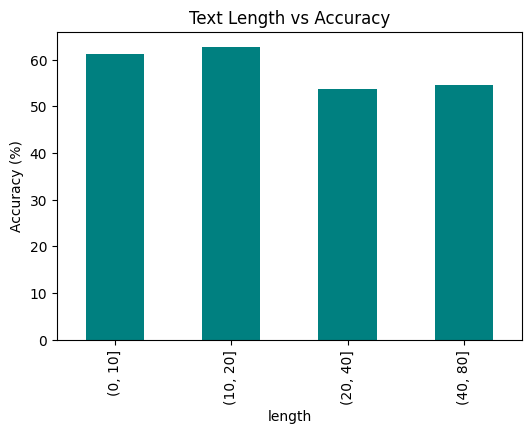

In [22]:
results_df["length"] = results_df["Text"].apply(lambda x: len(str(x).split()))
results_df["correct"] = results_df["True_Emotion"] == results_df["Predicted_Emotion"]

length_groups = pd.cut(results_df["length"], bins=[0,10,20,40,80])
length_accuracy = results_df.groupby(length_groups)["correct"].mean() * 100
print(length_accuracy)
length_accuracy.plot(kind="bar", color="teal", figsize=(6,4), ylabel="Accuracy (%)", title="Text Length vs Accuracy")
plt.show()


## 8. N-Gram Analysis: Misclassified vs Correct

In [9]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Prepare text groups
correct_df = results_df[results_df["True_Emotion"] == results_df["Predicted_Emotion"]]
incorrect_df = results_df[results_df["True_Emotion"] != results_df["Predicted_Emotion"]]

# Vectorize (use bigrams and unigrams)
vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=1000, token_pattern=r'\b\w+\b')

# Fit and transform misclassified texts
X_misclassified = vectorizer.fit_transform(incorrect_df["Text"])
misclassified_ngrams = pd.DataFrame(X_misclassified.toarray(), columns=vectorizer.get_feature_names_out())
misclassified_counts = misclassified_ngrams.sum().sort_values(ascending=False).head(20)

# Fit and transform correct texts
X_correct = vectorizer.fit_transform(correct_df["Text"])
correct_ngrams = pd.DataFrame(X_correct.toarray(), columns=vectorizer.get_feature_names_out())
correct_counts = correct_ngrams.sum().sort_values(ascending=False).head(20)

# Show top confusing n-grams vs top correct ones
print("🔴 Top n-grams in misclassified samples:")
print(misclassified_counts)

print("\n🟢 Top n-grams in correctly classified samples:")
print(correct_counts)


🔴 Top n-grams in misclassified samples:
و       599
به      377
از      355
که      319
در      206
این     190
با      154
رو      136
را      110
هم       95
من       89
تو       86
یه       77
بود      75
تا       69
برای     66
می       59
است      56
بدم      56
مردم     55
dtype: int64

🟢 Top n-grams in correctly classified samples:
و       811
که      417
به      416
از      396
در      269
این     231
رو      221
با      200
من      162
هم      146
تو      144
را      112
برای    110
یه      106
بود      99
است      87
همه      73
بدم      71
خیلی     70
تا       67
dtype: int64


## 9. Visualize Misclassified N-Grams

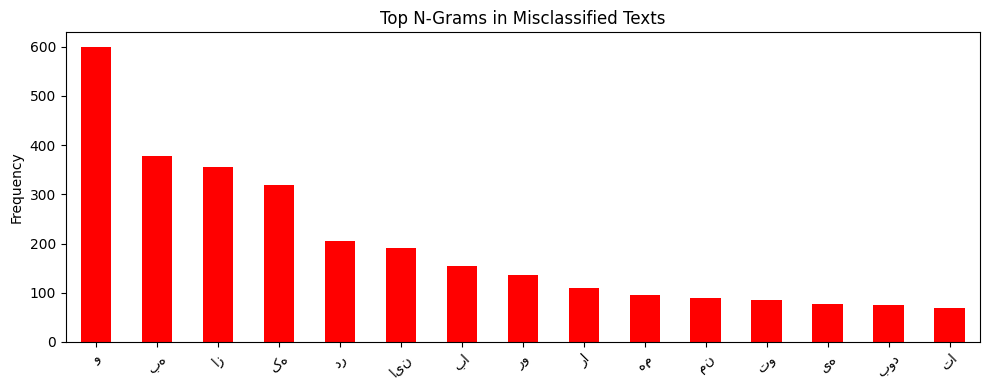

In [10]:
import matplotlib.pyplot as plt

misclassified_counts.head(15).plot(kind="bar", color="red", figsize=(10,4), title="Top N-Grams in Misclassified Texts")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Bar Chart for Precision, Recall, F1 by Emotion Class

c:\Anaconda\envs\YEAR2-1\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Anaconda\envs\YEAR2-1\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Anaconda\envs\YEAR2-1\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


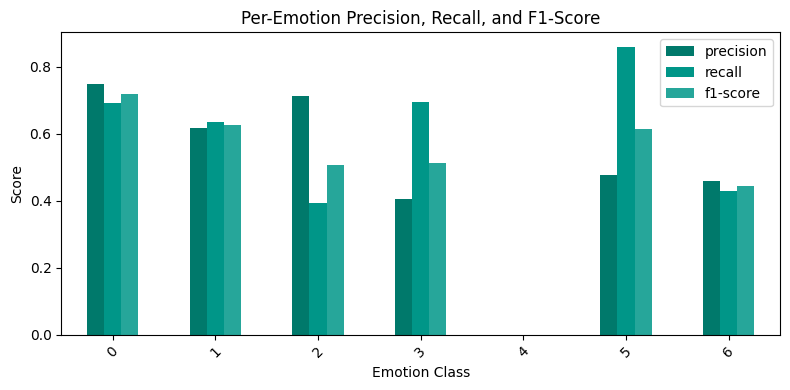

In [11]:
from sklearn.metrics import classification_report
import seaborn as sns

report = classification_report(
    results_df["True_Emotion"], 
    results_df["Predicted_Emotion"], 
    output_dict=True
)
scores = pd.DataFrame(report).transpose().drop(["accuracy","macro avg","weighted avg"])
scores[["precision","recall","f1-score"]].plot(kind="bar", figsize=(8,4), color=["#00796b","#009688","#26a69a"])
plt.title("Per-Emotion Precision, Recall, and F1-Score")
plt.ylabel("Score")
plt.xlabel("Emotion Class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 11. Bar Chart for Misclassification Count by True Emotion

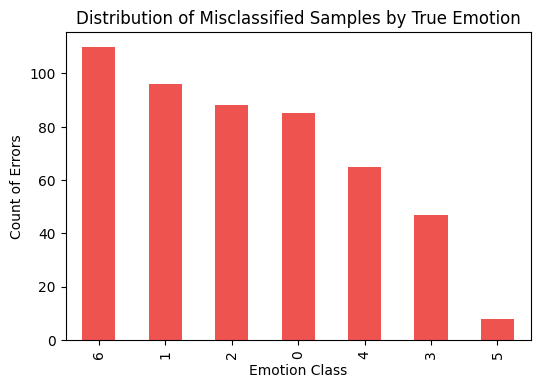

In [12]:
error_counts = errors_df["True_Emotion"].value_counts().sort_values(ascending=False)
error_counts.plot(kind="bar", color="#ef5350", figsize=(6,4))
plt.title("Distribution of Misclassified Samples by True Emotion")
plt.ylabel("Count of Errors")
plt.xlabel("Emotion Class")
plt.show()


## 12. Heatmap for Top Confusion Pairs

    True_Emotion  Predicted_Emotion  count
33             6                  3     51
4              0                  6     47
7              1                  3     39
31             6                  1     37
23             4                  3     32
12             2                  3     26
11             2                  1     23
5              1                  0     20
8              1                  5     18
14             2                  6     18


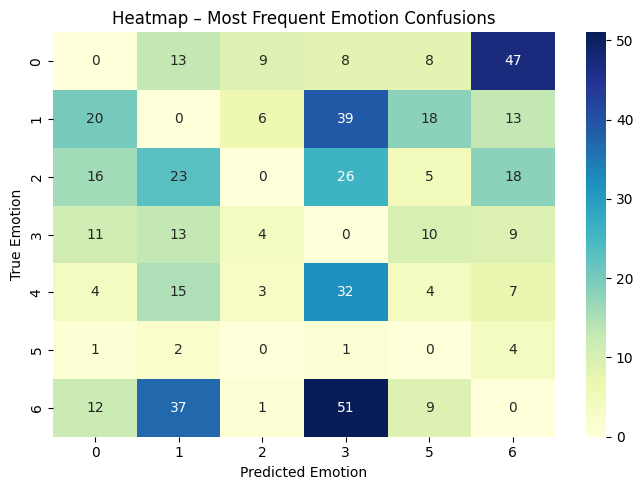

In [13]:
confusions = (
    results_df[results_df["True_Emotion"] != results_df["Predicted_Emotion"]]
    .groupby(["True_Emotion", "Predicted_Emotion"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(confusions.head(10))

import seaborn as sns

conf_matrix = confusions.pivot(index="True_Emotion", columns="Predicted_Emotion", values="count").fillna(0)
plt.figure(figsize=(7,5))
sns.heatmap(conf_matrix, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Heatmap – Most Frequent Emotion Confusions")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.tight_layout()
plt.show()


## 13.Top 10 Most Frequent Confusions as text pairs

In [14]:
confusions = (
    errors_df.groupby(["True_Emotion", "Predicted_Emotion"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
confusions.head(10)


,True_Emotion,Predicted_Emotion,count
33,6,3,51
4,0,6,47
7,1,3,39
31,6,1,37
23,4,3,32
12,2,3,26
11,2,1,23
5,1,0,20
8,1,5,18
14,2,6,18


## 14. Bar Chart for Top 10 Most Frequent Confusions

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17624\1677471110.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_confusions, x="pair", y="count", palette="Reds_r")


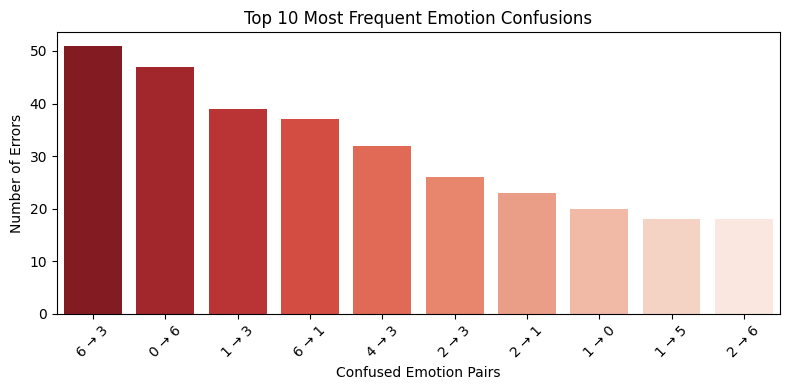

In [ ]:
confusions = (
    errors_df.groupby(["True_Emotion", "Predicted_Emotion"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

confusions["pair"] = confusions["True_Emotion"].astype(str) + " → " + confusions["Predicted_Emotion"].astype(str)

top_10_confusions = confusions.head(10)
plt.figure(figsize=(8,4))
sns.barplot(data=top_10_confusions, x="pair", y="count", palette="Reds_r")
plt.title("Top 10 Most Frequent Emotion Confusions")
plt.ylabel("Number of Errors")
plt.xlabel("Confused Emotion Pairs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
